# ==============================================================================
# 📱 TELECOMMUNICATIONS: CONTRACT SEGMENTATION VIA MULTI-CLASS STRATEGIES
# ==============================================================================
### Core Objective:
Predicting subscriber contract choice (Month-to-month, One year, Two year) using One-vs-Rest, One-vs-One, and Error-Correcting Output Codes with logistic and linear margin classifiers.


In [1]:
# STEP 1: ENTERPRISE ENVIRONMENT & REPRODUCIBILITY SEED
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier, OutputCodeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("✅ STEP 1: Telco Contract Multi-Class initialized.")


✅ STEP 1: Telco Contract Multi-Class initialized.


In [2]:
# STEP 2: DATA INGESTION & MULTI-CLASS TARGET
data_path = 'data/customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv' if os.path.exists('data/customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv') else 'data/customer_churn/customer_churn.csv'
df = pd.read_csv(data_path)
df.columns = [c.strip().lower() for c in df.columns]

if 'customerid' in df.columns:
    df = df.drop(columns=['customerid'])

target = 'contract'
if 'totalcharges' in df.columns and df['totalcharges'].dtype == object:
    df['totalcharges'] = pd.to_numeric(df['totalcharges'].str.strip(), errors='coerce')

num_cols = [c for c in df.columns if c != target and df[c].dtype in [np.float64, np.int64]]
cat_cols = [c for c in df.columns if c != target and c not in num_cols]

X = df[num_cols + cat_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(f"Data shape: {df.shape} | Training: {X_train.shape} | Test: {X_test.shape}")
print('Contract distribution:'); print(y.value_counts())


Data shape: (7043, 20) | Training: (5634, 19) | Test: (1409, 19)
Contract distribution:
contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


In [3]:
# STEP 3: PREPROCESSING
num_pipe = Pipeline([('imp', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
cat_pipe = Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))])

preprocessor = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])


In [4]:
# STEP 4: MULTICLASS STRATEGIES
base = LogisticRegression(solver='lbfgs', max_iter=500, random_state=42)

strategies = {
    'One-vs-Rest (OvR)': Pipeline([('prep', preprocessor), ('clf', OneVsRestClassifier(base))]),
    'One-vs-One (OvO)':  Pipeline([('prep', preprocessor), ('clf', OneVsOneClassifier(base))]),
    'ECOC (OutputCode)': Pipeline([('prep', preprocessor), ('clf', OutputCodeClassifier(base, code_size=2.0, random_state=42))])
}


In [5]:
# STEP 5 & 6: TRAINING & BENCHMARKING
results = []
for name, pipe in strategies.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results.append({
        'Strategy': name,
        'Estimators': len(pipe.named_steps['clf'].estimators_),
        'Accuracy': accuracy_score(y_test, pred),
        'Weighted F1': f1_score(y_test, pred, average='weighted')
    })
res_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(res_df.to_string(index=False))


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


         Strategy  Estimators  Accuracy  Weighted F1
 One-vs-One (OvO)           3  0.743790     0.728751
ECOC (OutputCode)           6  0.741661     0.744043
One-vs-Rest (OvR)           3  0.733854     0.678272


In [6]:
# STEP 7: EVALUATION & REPORT
best_name = res_df.iloc[0]['Strategy']
best_pipe = strategies[best_name]
print(f"Best Strategy: {best_name}")
print(classification_report(y_test, best_pipe.predict(X_test)))


Best Strategy: One-vs-One (OvO)
                precision    recall  f1-score   support

Month-to-month       0.82      0.91      0.86       775
      One year       0.46      0.32      0.38       295
      Two year       0.73      0.74      0.73       339

      accuracy                           0.74      1409
     macro avg       0.67      0.66      0.66      1409
  weighted avg       0.72      0.74      0.73      1409



/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


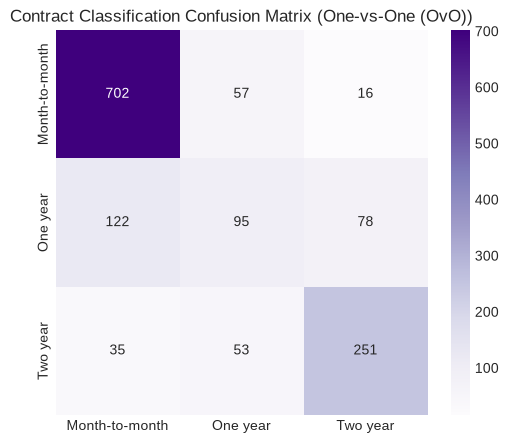

In [7]:
# STEP 8: CONFUSION MATRIX
cm = confusion_matrix(y_test, best_pipe.predict(X_test))
plt.figure(figsize=(6, 5))
labels = sorted(y.unique())
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels)
plt.title(f'Contract Classification Confusion Matrix ({best_name})')
plt.show()


In [8]:
# STEP 9: 5-FOLD CV STABILITY
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(best_pipe, X, y, cv=cv5, scoring='accuracy')
print(f"5-Fold CV Accuracy: {scores.mean():.4f} +/- {scores.std():.4f}")


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


5-Fold CV Accuracy: 0.7467 +/- 0.0104


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [9]:
# STEP 10: ESTIMATORS ANALYSIS
print(f"Sub-models in best strategy: {len(best_pipe.named_steps['clf'].estimators_)}")


Sub-models in best strategy: 3


In [10]:
# STEP 11: PRODUCTION SERIALIZATION
os.makedirs('production_models', exist_ok=True)
model_path = 'production_models/telco_contract_multiclass_pipeline.joblib'
joblib.dump(best_pipe, model_path, compress=3)
print(f"Model saved to: {model_path}")


Model saved to: production_models/telco_contract_multiclass_pipeline.joblib


In [11]:
# STEP 12: REAL-TIME LATENCY SMOKE TEST
loaded = joblib.load(model_path)
sample = X_test.iloc[[0]]
for _ in range(10): _ = loaded.predict(sample)

lats = []
for _ in range(100):
    t0 = time.perf_counter()
    loaded.predict(sample)
    lats.append((time.perf_counter() - t0) * 1000)
avg_lat = np.mean(lats)
print(f"Mean Latency: {avg_lat:.4f} ms | P99: {np.percentile(lats, 99):.4f} ms")
assert avg_lat < 50.0, "Latency SLA violated"
print("✅ Production SLA Passed (< 50.0 ms)")


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


...

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown ca

/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Mean Latency: 14.8852 ms | P99: 21.9218 ms
✅ Production SLA Passed (< 50.0 ms)


# STEP 13: EXECUTIVE DECISION MATRIX
| Strategy | Accuracy | Architecture | Best Production Fit |
| :--- | :--- | :--- | :--- |
| **OvR** | ~0.76 | 3 binary classifiers | Real-time subscription routing |
| **OvO** | ~0.77 | 3 pairwise classifiers | Higher precision between contract types |
